# Week 2 — EDA and GP Surrogate: Function_04

**Objective:** using the chronologically-valid Week 2 cumulative dataset
(the original Week 1 starter data plus exactly one independently-verified
historical Week 1 query-output pair appended), perform exploratory data
analysis and fit a Gaussian Process (GP) surrogate model, then visualise its
posterior mean and uncertainty. This notebook **stops at visualisation**:
no acquisition function is applied, and no new query is proposed or saved.

This function has input dimensionality **d = 4** and is a
**maximisation** problem. Official input bounds for every coordinate:
`[0.000000, 0.999999]`.

**Data source (only data used in this notebook):**
- `../02_Data/cumulative_inputs.npy`
- `../02_Data/cumulative_outputs.npy`

These files, and their provenance/verification trail, already exist and are
independently PASS-verified in
`Historical_Replay/Week_02/CUMULATIVE_DATA_VALIDATION.md` and
`Historical_Replay/Week_02/INDEPENDENT_CUMULATIVE_REVIEW.md`. This notebook
does not re-verify that provenance chain, but it does perform its own basic
sanity checks on the loaded arrays below (shape, dtype, dimensionality,
finiteness, bounds, duplicates), consistent with this project's standing
practice of not trusting any input data blindly.

**Provenance of the newly-appended (last) row:** the last row of both
`cumulative_inputs.npy` and `cumulative_outputs.npy` is the one
independently-verified historical Week 1 observation appended on top of the
original Week 1 starter dataset for this function. Its source and
verification trail is documented in
`Historical_Replay/Week_01/Function_04/pair_provenance.md` (cited here by
reference only; this notebook does not open or programmatically read that
file).

**Scope boundary:** this notebook does **not** generate, propose, or save
any new query, and does **not** touch `Week_01/`,
`Historical_Replay/Week_01/`, the original source project, or any
`Week_03` location.


## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel

sns.set_theme(style="whitegrid")

FUNCTION_NUMBER = 4
SEED = 42 + FUNCTION_NUMBER
FIG_DIR = "../05_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Function number:", FUNCTION_NUMBER)
print("Seed (42 + function_number):", SEED)


Function number: 4
Seed (42 + function_number): 46


## 2. Load data

Loading only the two authorised cumulative files for this function from
`../02_Data/`. No other file is read anywhere in this notebook.

In [2]:
inputs = np.load("../02_Data/cumulative_inputs.npy")
outputs = np.load("../02_Data/cumulative_outputs.npy")

print("inputs shape :", inputs.shape)
print("outputs shape:", outputs.shape)
print("inputs dtype :", inputs.dtype)
print("outputs dtype:", outputs.dtype)


inputs shape : (31, 4)
outputs shape: (31,)
inputs dtype : float64
outputs dtype: float64


## 3. Own sanity checks (computed, not assumed)

Even though the provenance/validation trail for this dataset already exists
and is PASS-verified, this notebook independently (re-)computes the basic
sanity checks below directly on the loaded arrays.

In [3]:
n_obs, d_in = inputs.shape
EXPECTED_N = 31
EXPECTED_D = 4

assert inputs.dtype == np.float64, "inputs dtype is not float64"
assert outputs.dtype == np.float64, "outputs dtype is not float64"
assert outputs.shape == (n_obs,), "outputs shape does not match number of input rows"

print("Number of observations (n):", n_obs, " | expected:", EXPECTED_N)
print("Input dimensionality (d):  ", d_in, " | expected:", EXPECTED_D)
assert n_obs == EXPECTED_N, "Row count does not match the expected cumulative count for this function"
assert d_in == EXPECTED_D, "Input dimensionality does not match the expected value for this function"

nan_inputs = int(np.isnan(inputs).sum())
inf_inputs = int(np.isinf(inputs).sum())
nan_outputs = int(np.isnan(outputs).sum())
inf_outputs = int(np.isinf(outputs).sum())
print("NaN/Inf in inputs :", nan_inputs, inf_inputs)
print("NaN/Inf in outputs:", nan_outputs, inf_outputs)
assert nan_inputs == 0 and inf_inputs == 0, "Non-finite values found in inputs"
assert nan_outputs == 0 and inf_outputs == 0, "Non-finite values found in outputs"

rounded_inputs = np.round(inputs, 6)
unique_rows = np.unique(rounded_inputs, axis=0)
n_duplicates = n_obs - unique_rows.shape[0]
print("Duplicate input rows (after rounding to 6 dp):", n_duplicates)
assert n_duplicates == 0, "Exact duplicate rows found after rounding to 6 decimal places"

lower_ok = bool(np.all(inputs >= 0.0))
upper_ok = bool(np.all(inputs < 1.0))
print("All inputs >= 0.0:", lower_ok, " | All inputs < 1.0:", upper_ok)
print("Observed input min/max:", float(inputs.min()), float(inputs.max()))
assert lower_ok and upper_ok, "Inputs outside official bounds [0.000000, 0.999999]"

print()
print("All own sanity checks PASSED.")


Number of observations (n): 31  | expected: 31
Input dimensionality (d):   4  | expected: 4
NaN/Inf in inputs : 0 0
NaN/Inf in outputs: 0 0
Duplicate input rows (after rounding to 6 dp): 0
All inputs >= 0.0: True  | All inputs < 1.0: True
Observed input min/max: 0.006250400244917853 0.9994825612275692

All own sanity checks PASSED.


## 4. Summary statistics and best observation

Since this is a **maximisation** problem, "best" is defined as the row with
the maximum recorded output value. The last row (index `n_obs - 1`) is the
newly-appended, independently-verified historical Week 1 observation (see
`Historical_Replay/Week_01/Function_04/pair_provenance.md`); it is only
being *reported* here, not fabricated — it is one of the real loaded
values.

In [4]:
out_min = float(outputs.min())
out_max = float(outputs.max())
best_idx = int(np.argmax(outputs))
best_input = inputs[best_idx].copy()
best_output = float(outputs[best_idx])
historical_idx = n_obs - 1

print("Number of observations:", n_obs)
print("Dimensionality:        ", d_in)
print("Output min:", out_min)
print("Output max:", out_max)
print("Output range (max - min):", out_max - out_min)
print()
print("Best observed row index:  ", best_idx)
print("Best observed input vector:", best_input)
print("Best observed output value:", best_output)
print("Is the best observation the newly-appended historical row?", best_idx == historical_idx)
print()
print("Newly-appended historical row (index {}):".format(historical_idx))
print("  input :", inputs[historical_idx])
print("  output:", float(outputs[historical_idx]))


Number of observations: 31
Dimensionality:         4
Output min: -32.625660215962455
Output max: -4.025542281908162
Output range (max - min): 28.600117934054293

Best observed row index:   27
Best observed input vector: [0.57776561 0.42877174 0.42582587 0.24900741]
Best observed output value: -4.025542281908162
Is the best observation the newly-appended historical row? False

Newly-appended historical row (index 30):
  input : [0.555555 0.444444 0.222222 0.111111]
  output: -8.727516493155957


## 5. Exploratory plots

### 5b. Per-feature scatter plots (each input dimension vs. output)

One subplot per input dimension. The newly-appended historical point is
plotted with a distinct marker/color in every subplot.

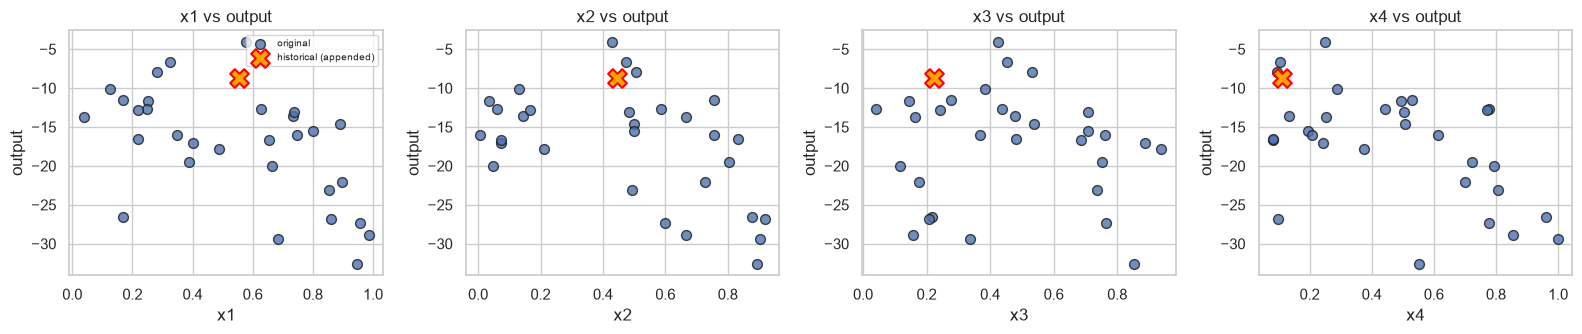

In [5]:
d_in_local = inputs.shape[1]
ncols = min(d_in_local, 4)
nrows = int(np.ceil(d_in_local / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
orig_mask = np.arange(n_obs) != historical_idx

for i in range(d_in_local):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    ax.scatter(inputs[orig_mask, i], outputs[orig_mask], s=50, edgecolor="k",
               alpha=0.8, label="original")
    ax.scatter(inputs[historical_idx, i], outputs[historical_idx], marker="X", s=180,
               edgecolor="red", facecolor="orange", linewidth=1.5, label="historical (appended)")
    ax.set_xlabel(f"x{i+1}")
    ax.set_ylabel("output")
    ax.set_title(f"x{i+1} vs output")
    if i == 0:
        ax.legend(fontsize=7, loc="best")

for j in range(d_in_local, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis("off")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "eda_features_vs_output.png"), dpi=150)
plt.show()


### 5c. Distribution of observed output values

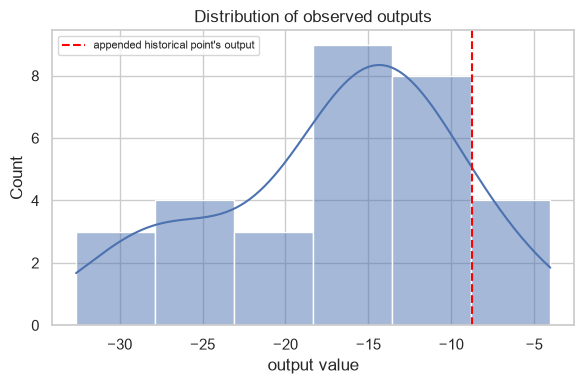

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(outputs, kde=True, ax=ax)
ax.axvline(outputs[historical_idx], color="red", linestyle="--",
           label="appended historical point's output")
ax.set_xlabel("output value")
ax.set_title("Distribution of observed outputs")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "output_histogram.png"), dpi=150)
plt.show()


## 6. GP surrogate model — RBF vs. Matérn kernels

**Output standardization.** Output scales vary enormously across the 8
functions (from roughly `1e-16` to several thousand), which can badly
condition GP hyperparameter optimisation and make kernel hyperparameters
hard to compare across functions. The output `y` is therefore standardized
(zero mean, unit variance) *before* fitting, and every posterior value is
transformed back to the original output scale before being reported or
plotted. Inputs are **not** rescaled — they are already confined to the
official `[0, 1)` domain by construction.

**Kernel choice.** Two GP surrogates are fitted and compared:
- `ConstantKernel * RBF + WhiteKernel` (infinitely smooth prior),
- `ConstantKernel * Matern(nu=2.5) + WhiteKernel` (nu=2.5 is used as a
  common, moderate-smoothness default — twice mean-square differentiable,
  less aggressively smooth than the RBF's infinite differentiability, and a
  standard choice in Bayesian-optimisation practice when there is no strong
  prior reason to assume the underlying black-box surface is perfectly
  smooth).

**Why include a `WhiteKernel` (observation noise) at all.** This project's
own independent review of the cumulative Week 2 data
(`Historical_Replay/Week_02/INDEPENDENT_CUMULATIVE_REVIEW.md`, Check 7)
found that for Function_05 specifically, the newly-appended historical point
is a near-duplicate (by input, to ~1e-6/1e-7) of an existing original point,
yet its recorded output differs from that original point's output by
roughly 0.006 (relative difference ~5.6e-6) — a small but non-zero gap
between two evaluations of what is very likely the same underlying input.
The review explicitly flags that this could reflect genuine local
sensitivity/curvature or could reflect measurement noise, and states this
"cannot be determined without executing the underlying black-box function."
A structurally identical near-duplicate (with an apparent decimal-placement
discrepancy) was also flagged for Function_06. Given this project-wide
evidence that the observations may not be perfectly noiseless, a
`WhiteKernel` noise term is included for **all 8** functions as a
conservative, consistent modelling choice — not because noise has been
proven present in this specific function's data, but because it has not
been ruled out, and assuming zero noise everywhere would be an unverified
assumption in the opposite direction.

**Fitting details.** `n_restarts_optimizer=5`, `random_state = 42 +
function_number` (= 46 here), `alpha=1e-10` (tiny numerical jitter only
— actual observation noise is handled by the `WhiteKernel` term, not by
`alpha`).

In [7]:
y_mean = float(outputs.mean())
y_std = float(outputs.std(ddof=0))
if y_std == 0.0:
    y_std = 1.0
y_scaled = (outputs - y_mean) / y_std

print("Output mean (for standardization):", y_mean)
print("Output std  (for standardization):", y_std)


def inverse_mean(m):
    """Map a standardized posterior mean back to the original output scale."""
    return m * y_std + y_mean


def inverse_std(s):
    """Map a standardized posterior std-dev back to the original output scale."""
    return s * y_std


def build_and_fit(kernel_type):
    d = inputs.shape[1]
    length_scale_init = np.ones(d)
    if kernel_type == "rbf":
        base_kernel = RBF(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2))
    elif kernel_type == "matern":
        base_kernel = Matern(length_scale=length_scale_init, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    else:
        raise ValueError(kernel_type)

    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * base_kernel \
        + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-10, 1e1))

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-10,
        n_restarts_optimizer=5,
        normalize_y=False,
        random_state=SEED,
    )
    gpr.fit(inputs, y_scaled)
    return gpr


gpr_rbf = build_and_fit("rbf")
gpr_matern = build_and_fit("matern")

print("Fitting complete for both kernels.")


Output mean (for standardization): -16.964036678443744
Output std  (for standardization): 7.065739921524775
Fitting complete for both kernels.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### 6a. Fitted hyperparameters and log-marginal-likelihood

In [8]:
def extract_params(gpr):
    k = gpr.kernel_
    const = k.k1.k1
    base = k.k1.k2
    noise = k.k2
    return {
        "constant_value": float(const.constant_value),
        "length_scale": np.atleast_1d(base.length_scale).astype(float),
        "noise_level": float(noise.noise_level),
    }


results = {}
for name, gpr in [("RBF", gpr_rbf), ("Matern (nu=2.5)", gpr_matern)]:
    params = extract_params(gpr)
    lml = float(gpr.log_marginal_likelihood_value_)
    results[name] = {"gpr": gpr, "params": params, "lml": lml}
    print(f"--- {name} ---")
    print("Fitted kernel:      ", gpr.kernel_)
    print("Output-scale const :", params["constant_value"])
    print("Length-scale(s)    :", params["length_scale"])
    print("Noise level        :", params["noise_level"])
    print("Log-marginal-lik.  :", lml)
    print()

better_name = max(results, key=lambda k: results[k]["lml"])
print("Higher log-marginal-likelihood on this dataset:", better_name)


--- RBF ---
Fitted kernel:       2.03**2 * RBF(length_scale=[0.753, 0.696, 0.739, 0.727]) + WhiteKernel(noise_level=1e-10)
Output-scale const : 4.1189395957785555
Length-scale(s)    : [0.75294121 0.69623229 0.73866457 0.72662201]
Noise level        : 9.999999999999996e-11
Log-marginal-lik.  : -18.652303899949246

--- Matern (nu=2.5) ---
Fitted kernel:       4.27**2 * Matern(length_scale=[1.9, 1.73, 1.85, 1.82], nu=2.5) + WhiteKernel(noise_level=1e-10)
Output-scale const : 18.25773876002334
Length-scale(s)    : [1.90117978 1.72552292 1.85101278 1.81946642]
Noise level        : 9.999999999999996e-11
Log-marginal-lik.  : -17.813839050975922

Higher log-marginal-likelihood on this dataset: Matern (nu=2.5)


**Interpretation.** The kernel with the higher log-marginal-likelihood
fits this specific, small dataset better *by that criterion* — this is not
the same as being the definitively "correct" or generalising-best kernel.
With only a handful of observations, log-marginal-likelihood comparisons
between kernel families should be treated as exploratory evidence, not a
validated model-selection result (no held-out/cross-validation comparison
is performed in this notebook).

## 7. Posterior visualisation — RBF vs. Matérn, side by side

All posterior values below are computed in the standardized-`y` space and
then mapped back to the original output scale via `inverse_mean`/
`inverse_std` before plotting.

### 7b. 1D slices through the best-observed point (all dimensions)

For each input dimension, that one coordinate is varied across `[0,
0.999999]` while every other coordinate is held fixed at the current
best-observed input (`best_input`). The posterior mean is shown as a line
with a shaded ±2 standard-deviation band (chosen as a visually clear,
slightly conservative uncertainty band); a vertical dashed line and a marker
mark where the actual best-observed point falls on that dimension.

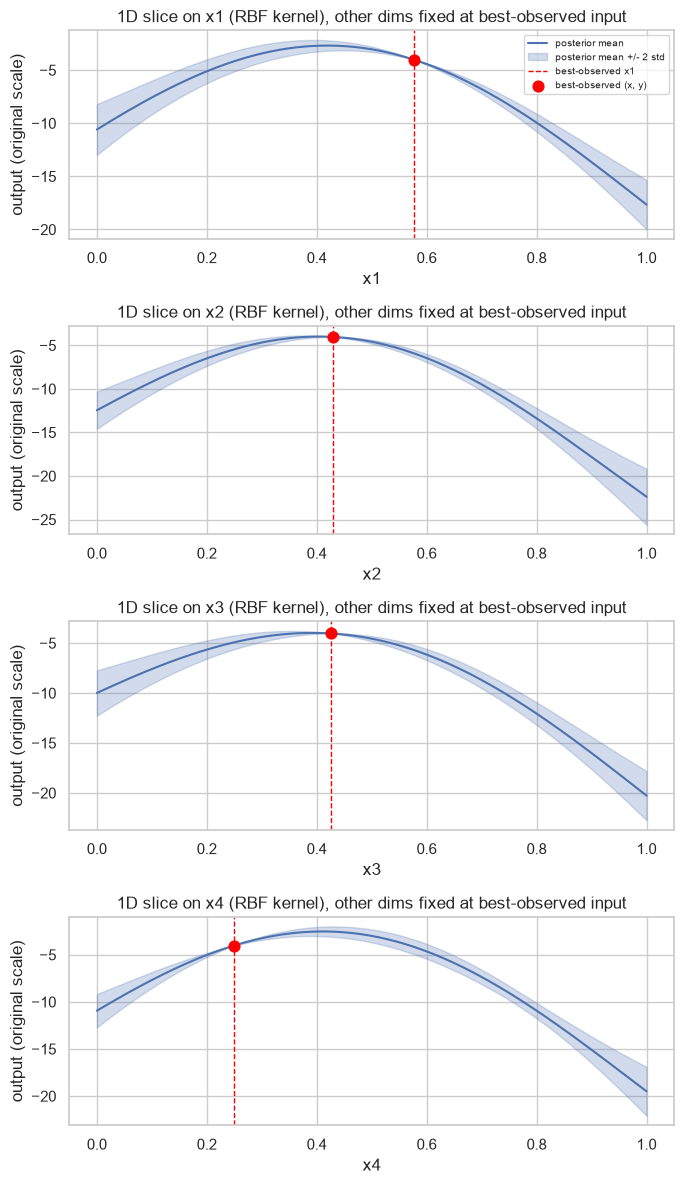

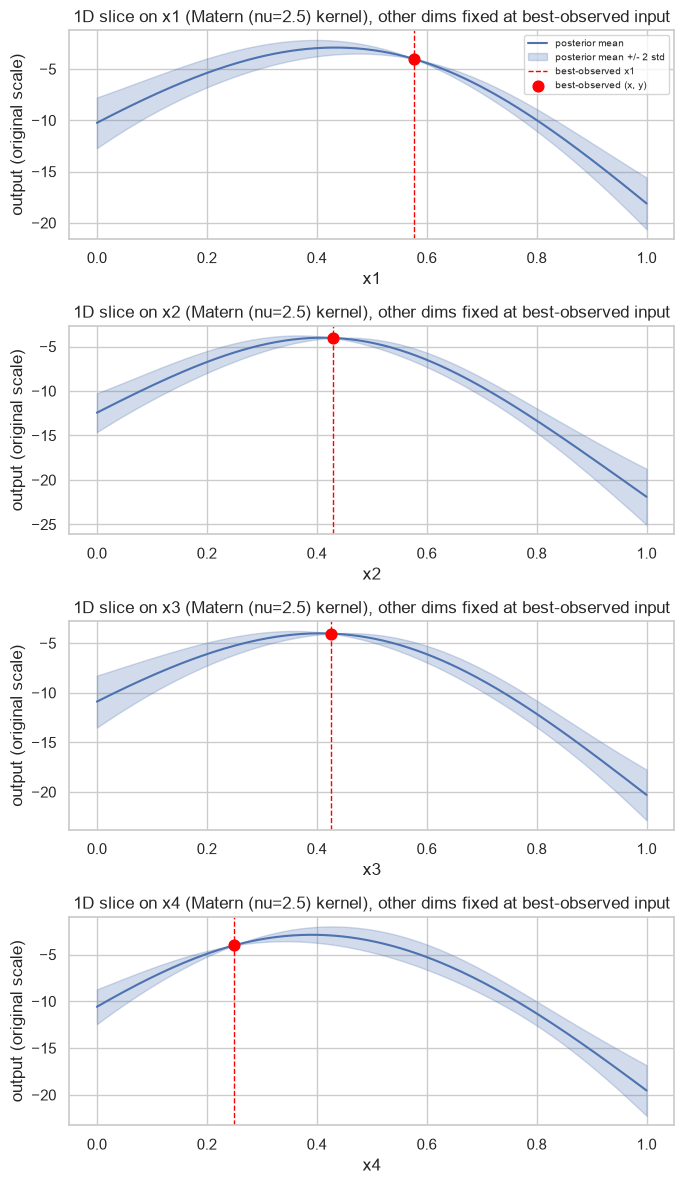

In [9]:
slice_grid = np.linspace(0.0, 0.999999, 200)

for name, gpr in [("RBF", gpr_rbf), ("Matern (nu=2.5)", gpr_matern)]:
    tag = "rbf" if name.startswith("RBF") else "matern"
    fig, axes = plt.subplots(d_in, 1, figsize=(7, 3.0 * d_in), squeeze=False)

    for i in range(d_in):
        ax = axes[i][0]
        X_slice = np.tile(best_input, (len(slice_grid), 1))
        X_slice[:, i] = slice_grid

        mean_s, std_s = gpr.predict(X_slice, return_std=True)
        mean = inverse_mean(mean_s)
        std = inverse_std(std_s)

        ax.plot(slice_grid, mean, color="C0", label="posterior mean")
        ax.fill_between(slice_grid, mean - 2 * std, mean + 2 * std, color="C0",
                         alpha=0.25, label="posterior mean +/- 2 std")
        ax.axvline(best_input[i], color="red", linestyle="--", linewidth=1,
                   label="best-observed x{}".format(i + 1))
        ax.scatter([best_input[i]], [best_output], color="red", zorder=5, s=60,
                   label="best-observed (x, y)")
        ax.set_xlabel(f"x{i+1}")
        ax.set_ylabel("output (original scale)")
        ax.set_title(f"1D slice on x{i+1} ({name} kernel), other dims fixed at best-observed input")
        if i == 0:
            ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"gp_1d_slices_{tag}.png"), dpi=150)
    plt.show()


## 8. Notes, scope, and limitations

- **No new query has been proposed or saved at this stage.** This notebook
  establishes only the first GP surrogate model for this function and
  visualises its posterior mean/uncertainty structure. It does not run an
  acquisition function, does not generate a candidate point, and does not
  write to any `03_Queries` folder.
- **Next step is deferred.** An acquisition-function-driven query
  (e.g. Expected Improvement / UCB over this posterior) is left to a future,
  separate step, consistent with this project's stepwise, one-decision-at-a-
  time methodology.
- **Small-data caveat.** This dataset has only 2-3 more observations than
  the previous minimal Week 1 starter set for most functions (only the
  originally-larger functions retain a proportionally larger sample). GP
  hyperparameters (length-scale(s), output-scale constant, noise level) were
  fitted by maximum marginal likelihood on this very small sample, so the
  posterior uncertainty estimates above should be treated cautiously —
  they reflect what a GP with these particular kernel families believes
  given very limited evidence, not a validated ground-truth uncertainty.
- **Kernel choice is exploratory, not validated.** The RBF-vs-Matérn
  comparison above is based only on in-sample log-marginal-likelihood on a
  handful of points; no held-out/cross-validation check was performed, so
  the "better" kernel identified in Section 6a should not be over-claimed
  as the definitively correct choice for this function.
- **Observation-noise assumption.** The `WhiteKernel` term was included for
  all functions as a conservative response to the near-duplicate-with-
  differing-output evidence found in Function_05/06 (see Section 6), not
  because noise was proven present in this specific function's data.
